# Cross-validation and model selection

## Motivation

In the previous lecture, we introduced the fundamentals of supervised learning
using `scikit-learn`, focusing on linear regression models and evaluating
predictive performance on a single train-test split.

Evaluating a model on a single split has important limitations:

1.  The estimated test error can vary considerably depending on the specific split
    of the data, especially when sample sizes are modest.
2.  If we use the test set repeatedly to select model complexity (such as the degree
    of a polynomial), we risk overfitting to that particular test set, compromising
    its role as an independent benchmark.

To address these challenges, in this lecture we study systematic hyperparameter
tuning and model selection using **cross-validation**. In particular, we will cover:

-   The logic of $k$-fold cross-validation and hyperparameter optimization
-   Semi-automatic and automated cross-validation in `scikit-learn` using
    [`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html),
    [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html),
    [`cross_validate()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html), and
    [`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html)
-   Advanced pipelines combining dimensionality reduction and regression via
    Principal Component Regression (PCR)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the local data/ directory
DATA_PATH = '../../data'


def load_ames_data(features, target):
    """
    Load Ames housing data from CSV file and select features and target variable

    Parameters
    ----------
    features : list of str
        List of column names to be used as features (or predictors)
    target : str
        Column name to be used as target variable (or response)

    Returns
    -------
    X : pd.DataFrame
        DataFrame containing selected features
    y : pd.Series
        Series containing the target variable
    """
    # Load data from CSV file
    file = f'{DATA_PATH}/ames_houses.csv'
    df = pd.read_csv(file)

    # Remove extreme outliers in terms of living area or lot area
    df = df.query('LivingArea <= 350 & LotArea <= 5000')

    # Drop any missing obs in selected columns
    columns = features + [target]
    df = df.dropna(subset=columns)

    # Select features and target variable
    X = df[features]
    y = df[target]

    return X, y

***
## Optimizing hyperparameters with cross-validation

### Outline of hyperparameter tuning

Previously, we discussed some ways to evaluate the model fit (MSE and R²) but did not specify what to do with this information. In this section, we demonstrate how we can use these measures to tune parameters which govern the estimation process, such as the polynomial degree from the previous section. Such parameters are usually called *hyperparameters* to clearly distinguish them from the parameters that are estimated by the model (e.g., the coefficients of a linear model).

Tuning hyperparameters, estimating the model, and evaluating its generalizability cannot be done based on the same dataset, as these steps then become interdependent (for the same reason we don't want to evaluate the model fit on the training sample as this would lead to overfitting). To this end, in machine learning we often split the data into *three* parts: the training, validation, and test datasets. Models are estimated on the training sample, while the choice of hyperparameters is determined based on the validation sample. Finally, model generalizability is determined based on the test sample which was not used in estimation or tuning at all.

However, because we might not have enough data to split the sample this way, we usually perform so-called *cross-validation*, which is illustrated in the figure below:

1. We split the overall dataset into training and test sub-samples. 
2. The training dataset is further split into $K$ so-called *folds*.
    1. For each $k = 1,\dots,K$, a smaller training sample is formed by excluding
        the $k$-th fold and estimating the model on the remaining $K-1$ folds.
        We then compute the chosen metric of model fit on the $k$-th fold 
        and store the result.
    2. After cycling through all $K$ folds, we have $K$ values of our desired
        metric, which we then average to get our final measure.
        Hyperparameters are tuned by minimizing (or maximizing) this averaged
        metric.
    
3.  Once hyperparameter tuning is complete, we evaluate the model on
    the test dataset.

![CV split](cv_split.svg)

In this unit we will skip the final step of assessing generalizability on the test dataset. Consequently, when running cross-validation, we will only use training/validation datasets and we will use the terms "validation" and "test" interchangeably.

The `scikit-learn` 
[documentation](https://scikit-learn.org/stable/modules/cross_validation.html) contains a wealth of additional information on cross-validation. Another method to perform hyperparameter tuning is 
[grid search](https://scikit-learn.org/stable/modules/grid_search.html).

***
### Example: Tuning of the polynomial degree

To illustrate the concept, we demonstrate the procedure outlined above by tuning the polynomial degree for the example covered in the previous section by minimizing the root mean squared error (RMSE).

We recreate the dataset in the same way as before, using `LivingArea` and `LotArea` as explanatory variables.

In [2]:
# Load Ames housing data
features = ['LivingArea', 'LotArea']
target = 'SalePrice'

X, y = load_ames_data(features, target)

`scikit-learn` offers a multitude of approaches to perform this parameter tuning:

1.  `scikit-learn` can split the sample into training and test sets for each fold of the cross-validation but we perform the model fitting for each of these splits manually ("semi-automatic").
2.  We can use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to let `scikit-learn` compute the desired score for each split *on the test sample*.
3.  Alternatively, [`cross_validate()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) is a more generic version of `cross_val_score()` which can return additional objects of interest, for example the score evaluated on the training sample.
4. Finally, [`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html) can be used to perform the whole cross-validation process almost fully automatically as this function can vary the hyperparameters directly so we don't have to loop over them.

We explore each of these approaches in turn.

***
#### Semi-automatic cross-validation with `KFold`

We now iterate over the candidate polynomial degrees $d = 1,\dots,5$ and apply $k$-fold cross-validation with 10 folds. There is no need to manually split the sample into training and validation/test sub-sets. Instead, we use the 
[`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold)
class to automatically create the splits for us. Once we have created an instance with the desired number of folds, e.g., `KFold(n_splits=10)`, we can call the `split()` method which iterates through all possible combinations of training and test datasets and returns the array indices for each.

Note that in the code below, we have to be a little careful on how we create the pipeline for each polynomial degree: 

-   For $d=0$, the model only has an intercept. We need to call [`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) with `include_bias=True`, otherwise there are no explanatory variables and the code fails.
-   On the other hand, for $d > 0$, and in particular for large $d$, the polynomials are so large in magnitude that this can lead to numerical instability. It is therefore good practice to rescale features using the [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). However, the intercept (bias) should never be standardized, so we need to create the polynomials with `include_bias=False` and instead estimate the model with an intercept by creating `LinearRegression(fit_intercept=True)`.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

degrees = np.arange(0, 6)

rmse_train_mean = []
rmse_test_mean = []

for d in degrees:
    # Create pipeline to transform and fit the model. Pipeline depends
    # on polynomial degree!
    if d == 0:
        # Intercept-only model
        pipe = make_pipeline(
            PolynomialFeatures(degree=d, include_bias=True),
            LinearRegression(fit_intercept=False),
        )
    else:
        # Model with polynomial terms: need to standardize features for
        # numerical stability
        pipe = make_pipeline(
            PolynomialFeatures(degree=d, include_bias=False),
            StandardScaler(),
            LinearRegression(fit_intercept=True),
        )

    rmse_train_fold = []
    rmse_test_fold = []

    # Create 10 folds
    folds = KFold(n_splits=10)

    # Iterate through all combinations of training/test data
    for itrain, itest in folds.split(X, y):
        # Extract training data for this split
        X_train = X.iloc[itrain]
        y_train = y.iloc[itrain]

        # Extract test (or validation) data for this split
        X_test = X.iloc[itest]
        y_test = y.iloc[itest]

        # Fit model on training data for given degree
        pipe.fit(X_train, y_train)

        # Predict response on train and test data
        y_train_hat = pipe.predict(X_train)
        y_test_hat = pipe.predict(X_test)

        # Compute RMSE as model fit measure
        rmse_train = root_mean_squared_error(y_train, y_train_hat)
        rmse_test = root_mean_squared_error(y_test, y_test_hat)

        # Store RMSE for current split
        rmse_train_fold.append(rmse_train)
        rmse_test_fold.append(rmse_test)

    # Store average MSE for current polynomial degree
    rmse_train_mean.append(np.mean(rmse_train_fold))
    rmse_test_mean.append(np.mean(rmse_test_fold))

# Convert to NumPy arrays
rmse_train_mean = np.array(rmse_train_mean)
rmse_test_mean = np.array(rmse_test_mean)

# Print average RMSE for all polynomial degrees
rmse_test_mean

array([78.10225405, 54.06796801, 53.7579006 , 53.52612724, 55.57874839,
       67.2402846 ])

This code returns an array of 5 averaged RMSEs, one for each $d = 0, \dots, 5$. We can now find the optimal $d$ by picking the one which has the lowest mean squared error in the test samples using the
[`argmin()`](https://numpy.org/doc/stable/reference/generated/numpy.argmin.html)
function which returns the *index* of the smallest array element.

In [4]:
# Find index of polynomial degree with smallest RMSE
imin = np.argmin(rmse_test_mean)

# RMSE-minimizing polynomial degree
dmin = degrees[imin]

print(f'Polynomial degree with minimum RMSE: {dmin}')

Polynomial degree with minimum RMSE: 3


Finally, it is often instructive to visualize how the RMSE evolves as a function of the hyperparameter we want to tune.

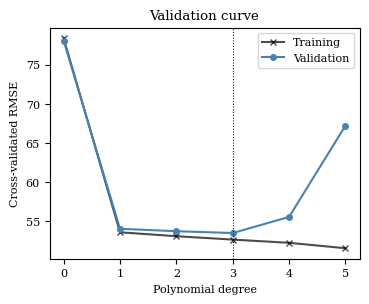

In [5]:
plt.plot(
    degrees, rmse_train_mean, c='black', marker='x', ms=4, alpha=0.7, label='Training'
)
plt.plot(degrees, rmse_test_mean, c='steelblue', marker='o', ms=4, label='Validation')
plt.xlabel('Polynomial degree')
plt.ylabel('Cross-validated RMSE')
plt.xticks(degrees)
plt.axvline(imin, ls=':', lw=0.75, c='black')
plt.title('Validation curve')
_ = plt.legend()

Here we see that for $d=0$ (the intercept-only model), the model underfits the data leading to a high prediction error. However, higher $d$'s do not always translate into a better fit. For $d = 5$, the model vastly overfits the data, resulting in poor performance in the test sample and a very large RMSE.

***
#### Automatically computing scores on all folds using `cross_val_score()`

The code implemented above to run cross-validation was needlessly complex even though we leveraged the [`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) class to do the sample splitting for us. Fortunately, `scikit-learn` provides us with even more convenience functions that further simplify this process.
For example, if we want to perform tuning based on a single score (such as the root mean squared error), we can instead use 
[`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html). This function requires us to specify an estimator (or a pipeline), the number of folds to use for cross-validation (`cv=10`)
and the metric to evaluate. For example, if we want to compute the RMSE, we would pass the argument 
`scoring='neg_root_mean_squared_error'`. Note that the function returns the *negative* RMSE which we need to correct manually.

See the 
[documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter)
for a complete list of valid metrics that can be passed as `scoring` arguments. Alternatively, `scikit-learn` lists available metrics by running

```python
import sklearn.metrics
sklearn.metrics.get_scorer_names()
```

The following code re-implements the k-fold cross-validation from earlier
using [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html):

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

degrees = np.arange(6)

# cross_val_score() only returns scores for test data
rmse_test_mean = []

for d in degrees:
    # Create pipeline to transform and fit the model. Pipeline depends
    # on polynomial degree!
    if d == 0:
        # Intercept-only model
        pipe = make_pipeline(
            PolynomialFeatures(degree=d, include_bias=True),
            LinearRegression(fit_intercept=False),
        )
    else:
        # Model with polynomial terms: need to standardize features for
        # numerical stability
        pipe = make_pipeline(
            PolynomialFeatures(degree=d, include_bias=False),
            StandardScaler(),
            LinearRegression(fit_intercept=True),
        )

    # Compute negative RMSE for all 10 folds
    score = cross_val_score(pipe, X, y, scoring='neg_root_mean_squared_error', cv=10)

    # Function returns NEGATIVE RMSE, correct this here!
    rmse_test_mean.append(np.mean(-score))

# Convert to NumPy array
rmse_test_mean = np.array(rmse_test_mean)

# Print average RMSE for all polynomial degrees
rmse_test_mean

array([78.10225405, 54.06796801, 53.7579006 , 53.52612724, 55.57874839,
       67.2402846 ])

The RMSE-minimizing degree is of course the same as before:

In [7]:
imin = np.argmin(rmse_test_mean)
dmin = degrees[imin]

print(f'Polynomial degree with min. RMSE: {dmin}')

Polynomial degree with min. RMSE: 3


***
#### Automatically computing scores on all folds using `cross_validate()`

One disadvantage of `cross_val_score()` is that it only returns the scores evaluated on the test sample. If we want to plot the validation curve for both the training and test samples as we did earlier, we have to use a different function which is capable of returning both.

To this end, we can use 
[`cross_validate()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) which is more flexible in terms of its return values, but is otherwise almost identical to `cross_val_score()`.

It is straightforward to adapt the code from above to use `cross_validate()` instead:

In [8]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline

degrees = np.arange(6)

# Lists to store average RMSE for train and test data for all polynomial degrees
rmse_test_mean = []
rmse_train_mean = []

for d in degrees:
    # Create pipeline to transform and fit the model. Pipeline depends
    # on polynomial degree!
    if d == 0:
        # Intercept-only model
        pipe = make_pipeline(
            PolynomialFeatures(degree=d, include_bias=True),
            LinearRegression(fit_intercept=False),
        )
    else:
        # Model with polynomial terms: need to standardize features for
        # numerical stability
        pipe = make_pipeline(
            PolynomialFeatures(degree=d, include_bias=False),
            StandardScaler(),
            LinearRegression(fit_intercept=True),
        )

    # Compute negative RMSE for all 10 folds, return results for both train and
    # test data in a dictionary
    scores = cross_validate(
        pipe,
        X,
        y,
        scoring='neg_root_mean_squared_error',
        cv=10,
        return_train_score=True,
    )

    # Function returns NEGATIVE RMSE, correct this here!
    rmse_test_mean.append(np.mean(-scores['test_score']))
    rmse_train_mean.append(np.mean(-scores['train_score']))

# Convert to NumPy array
rmse_test_mean = np.array(rmse_test_mean)
rmse_train_mean = np.array(rmse_train_mean)

# Print average RMSE on the test sample for all polynomial degrees
rmse_test_mean

array([78.10225405, 54.06796801, 53.7579006 , 53.52612724, 55.57874839,
       67.2402846 ])

As before, we arrive at the same optimal polynomial degree of 3:

In [9]:
imin = np.argmin(rmse_test_mean)
dmin = degrees[imin]

print(f'Polynomial degree with min. RMSE: {dmin}')

Polynomial degree with min. RMSE: 3


However, unlike `cross_val_score()`, `cross_validate()` can also return the score evaluated on the training samples, allowing us to recreate the validation curve we encountered earlier:

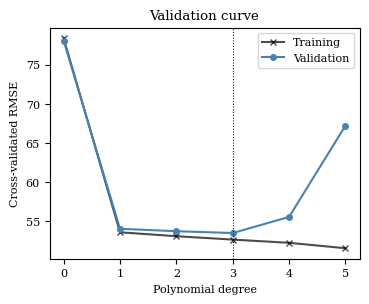

In [10]:
plt.plot(
    degrees, rmse_train_mean, c='black', marker='x', ms=4, alpha=0.7, label='Training'
)
plt.plot(degrees, rmse_test_mean, c='steelblue', marker='o', ms=4, label='Validation')
plt.xlabel('Polynomial degree')
plt.ylabel('Cross-validated RMSE')
plt.xticks(degrees)
plt.axvline(imin, ls=':', lw=0.75, c='black')
plt.title('Validation curve')
_ = plt.legend()

***
#### Automatically computing the validation curve

`scikit-learn` provides an even more automated API to perform the cross-validation using the function 
[`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html). 
To compute some score such as the RMSE for all folds at once, we don't even have to loop over the hyperparameter of interest (in this case the polynomial degree), but can leave this to [`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html). This process works as follows:

1.  We create an instance of an estimator (or estimator pipeline) to be used for the cross-validation.
2.  We specify which parameter should be cross-validated (using the argument `param_name`) and the set of 
    candidate values to be used for cross-validation (argument `param_range`).
3.  The function [`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html) returns the desired score, which needs to be specified using the `scoring` argument.
    The list of acceptable scorers is the same as in the previous section.

To demonstrate, we recreate the validation curve from the earlier example, but we restrict our attention to polynomial degrees $d>0$ as we then don't have to create a separate pipeline for the intercept-only model.

In [11]:
from sklearn.model_selection import validation_curve
from sklearn.pipeline import Pipeline

# Candidate polynomial degrees (ignore intercept-only model)
degrees = np.arange(1, 6)

# Create pipeline for polynomial features and linear regression.
# The degree of the polynomial DOES NOT MATTER at this point.
pipe = Pipeline(
    steps=[
        ('poly', PolynomialFeatures(degree=0, include_bias=False)),
        ('scale', StandardScaler()),
        ('lr', LinearRegression(fit_intercept=True)),
    ]
)

# Compute the RMSEs for each degree and each split, returning arrays of
# size len(degrees) x 10.
train_scores, test_scores = validation_curve(
    estimator=pipe,
    X=X,
    y=y,
    param_name='poly__degree',
    param_range=degrees,
    scoring='neg_root_mean_squared_error',
    cv=10,
)

In [12]:
# Compute mean for each degree (scores returned by function are
# NEGATIVE RMSEs)
rmse_train_mean = np.mean(-train_scores, axis=1)
rmse_test_mean = np.mean(-test_scores, axis=1)

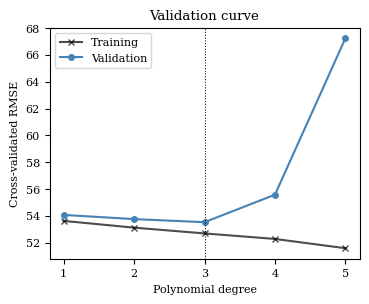

In [13]:
plt.plot(
    degrees, rmse_train_mean, c='black', marker='x', ms=4, alpha=0.7, label='Training'
)
plt.plot(degrees, rmse_test_mean, c='steelblue', marker='o', ms=4, label='Validation')
plt.xlabel('Polynomial degree')
plt.ylabel('Cross-validated RMSE')
plt.xticks(degrees)
plt.axvline(imin, ls=':', lw=0.75, c='black')
plt.title('Validation curve')
_ = plt.legend()

***
## Advanced pipelines and cross-validation: Principal component regression (PCR)

We close the section on cross-validation and hyperparameter tuning with a more complex example which also demonstrates a more advanced use of `scikit-learn` pipelines.

To this end, we implement principal component regression (PCR) with `scikit-learn`. The idea behind PCR is that we can address issues of overfitting and multicollinearity inherent in linear models without regularization by only using a subset of the variation in the explanatory variables.
This subset is obtained by using only a few principal components
(see [Principal component analysis](https://en.wikipedia.org/wiki/Principal_component_analysis))
which capture most of the variation in the data. You can think of principal component analysis as a method of feature extraction, as opposed to feature selection where we manually pick only a few explanatory variables.

In [14]:
# Load Ames data with additional features
features = ['LivingArea', 'LotArea', 'YearBuilt', 'OverallQuality']
target = 'SalePrice'

X, y = load_ames_data(features, target)

#### Fitting the principal component regression

We first create a pipeline with four steps:

1.  As before, we create polynomial interactions of all explanatory variables using [`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).
2.  We standardize the features created in the first step. This is crucial for principal component analysis
    as it is very sensitive to data scaling.
3.  We extract only a few principal components using 
    [`PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).
    The most important argument here is `n_components`, which can be either an integer
    specifying the number of components to use, or a floating point number in the open interval
    $(0, 1)$ which selects the number of components such that the amount of variance explained
    is greater than the value of `n_components`.
4.  The last step is a [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), as before. It is important to specify
    `fit_intercept=True` in this step since all variables have been standardized prior to the PCA
    step, and hence the model wouldn't be able to match the mean of the target variable
    without an intercept.

Note that we use [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) to create the pipeline instead of the convenience function
[`make_pipeline()`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) so that we can explicitly name the pipeline steps.
This will come in handy later.

In [15]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Create pipeline for principal component regression
pipe_pcr = Pipeline(
    steps=[
        ('poly', PolynomialFeatures(degree=5, include_bias=False)),
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=0.9)),
        ('lr', LinearRegression(fit_intercept=True)),
    ]
)

With the pipeline in hand, we can fit the model (for this exercise, we ignore the train-test split):

In [16]:
pipe_pcr.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['LivingArea','LotArea','YearBuilt','OverallQuality']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",5
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


We can use the named pipeline steps to extract information about the data transformation in the [`PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) layer.
For example, we can extract the fraction of variance explained by each component and plot it as follows:

In [17]:
# Extract fraction of variance explained by each principal component.
# Note that the name of the pipeline step is the one assigned when creating the
# pipeline.
var_expl = pipe_pcr.named_steps['pca'].explained_variance_ratio_
var_expl

array([0.60110876, 0.21964345, 0.08389025])

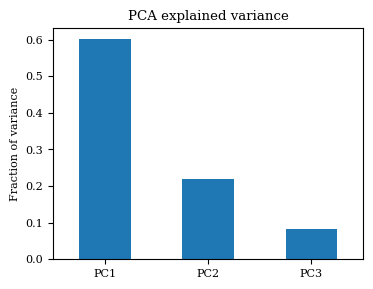

In [18]:
# Use pandas plotting functions to create bar plot
_ = pd.Series(var_expl, index=[f'PC{i + 1}' for i in range(len(var_expl))]).plot.bar(
    ylabel='Fraction of variance', title='PCA explained variance', rot=0
)

#### Cross-validation for principal component regression

Finally, we can perform hyperparameter tuning for the principal component regression as well. This is slightly complicated by the fact that we now have *two* hyperparameters:

1.  The maximum polynomial degree used to create the polynomial features.
2.  The number of principal components to use for PCR (or equivalently, the share of explained variance).

For this case, `scikit-learn` provides the 
[`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
class which performs grid search over a set of parameters which are specified
using the `param_grid` argument. This argument is expected to be a dictionary with
the parameter names as keys. 

Note that the parameter names are composed of two parts:

1.  the name of the pipeline step that should be tuned; and 
2.  the name of the attribute to be varied. 

These need to be separated by `'__'` so that the parameter name is
`STEP__ATTRIBUTE`.

In [19]:
import numpy as np
from sklearn.model_selection import GridSearchCV

# Define grid of hyperparameters
param_grid = {
    'poly__degree': np.arange(1, 6),
    'pca__n_components': np.linspace(0.9, 0.999999, 20),
}

# Create GridSearchCV object
pcr_cv = GridSearchCV(
    estimator=pipe_pcr,  # Estimator pipeline
    param_grid=param_grid,  # Grid of hyperparameters
    scoring='neg_root_mean_squared_error',  # Scoring criterion
    cv=10,  # Number of folds for CV
    n_jobs=-1,  # Use all available CPU cores
    refit=True,  # Refit model with best hyperparameters
)

# Run grid search
pcr_cv.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'pca__n_components': array([0.9 ..., 0.999999 ]), 'poly__degree': array([1, 2, 3, 4, 5])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbo

Once grid search is complete, we can obtain the best parameter combination from the `best_params_` attribute, and the best score (negative RMSE in this case) from the `best_score_` attribute:

In [20]:
# Extract best cross-validated hyperparameters
pcr_cv.best_params_

{'pca__n_components': np.float64(0.999999), 'poly__degree': np.int64(3)}

In [21]:
# Print RMSE (averaged over folds) for the best model
print(f'Best RMSE: {-pcr_cv.best_score_:.3f}')

Best RMSE: 28.961


Moreover, from the PCA step we can read off how many components were selected in the process:

In [22]:
# Number of total polynomial features in the best model
features_in = pcr_cv.best_estimator_.named_steps['pca'].n_features_in_
# Number of principal components in the best model
n_components = pcr_cv.best_estimator_.named_steps['pca'].n_components_

print(f'Number of polynomial features: {features_in}')
print(f'Number of principal components: {n_components}')

Number of polynomial features: 34
Number of principal components: 24


Last, we recreate the bar chart of the variance explained by each component in the best model:

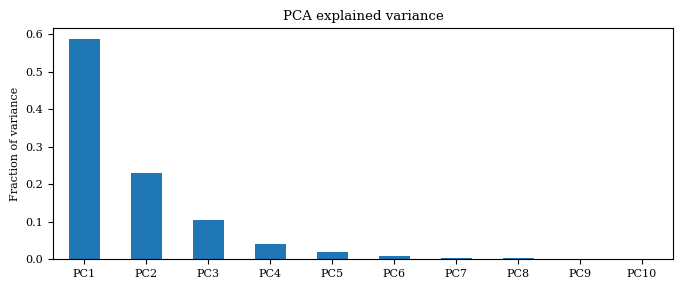

In [23]:
var_expl = pcr_cv.best_estimator_.named_steps['pca'].explained_variance_ratio_[:10]
_ = pd.Series(var_expl, index=[f'PC{i + 1}' for i in range(len(var_expl))]).plot.bar(
    ylabel='Fraction of variance', title='PCA explained variance', rot=0, figsize=(8, 3)
)

<div style="padding: 0.8em 1em 0.5em 1em; border: 2pt solid #1d91c0;">
<p style="font-weight: bold; font-size: 1.5em; color: #1d91c0;">Your turn</p>

1. Add the variables `YearRemodeled`, `Bedrooms`, and `Bathrooms`
   to the feature set and rerun the cross-validation.
2. What happens to the RMSE and the number of principal components of the best model?
</div>
<span style="display: none;">YourTurnEnd</span>

***
## List of functions used in this lecture

The following list contains the central functions covered in this lecture. Each
function name is linked to the official API documentation which you can consult for
more details regarding function arguments and return values. The [[go to section]]()
links to the relevant section in this notebook.

### NumPy functions

- [`argmin()`](https://numpy.org/doc/stable/reference/generated/numpy.argmin.html): Function to return the indices of the minimum values along an axis. [[go to section]](#example:-tuning-of-the-polynomial-degree)

### scikit-learn classes and functions

- [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html): Class for exhaustive search over specified parameter values for an estimator. [[go to section]](#cross-validation-for-principal-component-regression)
- [`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold): Class for K-Folds cross-validator. [[go to section]](#example:-tuning-of-the-polynomial-degree)
- [`PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html): Class for principal component analysis (PCA). [[go to section]](#fitting-the-principal-component-regression)
- [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline): Class to build a pipeline of transforms with a final estimator. [[go to section]](#example:-tuning-of-the-polynomial-degree)
- [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html): Class to standardize features by removing the mean and scaling to unit variance. [[go to section]](#example:-tuning-of-the-polynomial-degree)
- [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html): Function to evaluate a score by cross-validation. [[go to section]](#automatically-computing-scores-on-all-folds-using-cross_val_score())
- [`cross_validate()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate): Function to evaluate metric(s) by cross-validation. [[go to section]](#automatically-computing-scores-on-all-folds-using-cross_validate())
- [`make_pipeline()`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html): Function to construct a Pipeline from the given estimators. [[go to section]](#example:-tuning-of-the-polynomial-degree)
- [`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html): Function to determine training and test scores for varying parameter values. [[go to section]](#automatically-computing-the-validation-curve)

***
## Optional exercises

### Exercise 1: Optimizing hyperparameters with validation curves

In the lecture, we explored several ways to perform cross-validation. In this exercise, you are asked 
to use one of these methods to tune the polynomial degree of a model estimated on synthetic data.

Consider the following model where $y$ is a non-linear trigonometric function of $x$ and includes an additive error term $\epsilon$,
$$
y_i = f(x_i) + \epsilon_i\,, \qquad f(x) = \sin\bigl(2 \pi (x + 0.1) \bigr)
$$
and $x$ and $\epsilon$ are assumed to be independent.

1.  Create a sample of $N=100$ realizations of $(x_i, \epsilon_i)$ using a seed 1234 for the random number generator. 
    Draw the $x_i$ from the standard uniform distribution on $[0, 1]$ and 
    let $\epsilon \stackrel{\text{iid}}{\sim} N(0, 0.5^2)$.
    Compute $y_i$ according to the equation above.

    *Hint:* The sine function and the constant $\pi$ are implemented as `np.sin()` and `np.pi` in NumPy.
    
2.  Create a sample scatter plot of $(x_i, y_i)$ and add a line showing the true relationship between $x$ and $y$ 
    (without measurement error).

3.  Assume you don't know the true model and you want to fit the target $y$ to a polynomial in $x$. 
    To this end, create a [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
    that performs the polynomial transformation and the fitting of the linear model. You can use any value for 
    `PolynomialFeatures(degree=...)` at this point.

4.  Use the convenience function 
    [`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html)
    to compute the MSE for *each* $d = 0,\dots,15$ and 10 cross-validation splits in a single call:

    ```python
    train_scores, test_scores = validation_curve(
        estimator=...,
        ...,
        param_name='polynomialfeatures__degree',
        param_range=degrees,
        scoring='neg_mean_squared_error', 
        cv=10
    )
    ```

    To do this, the argument `estimator` specifies the model to use (i.e., the pipeline you created 
    in the previous part), `param_name` specifies which parameter needs to be varied, and `param_range` determines
    the set of parameter values that are evaluated. The `scoring` argument determines which metric is computed 
    and returned.

    Since our estimator is a pipeline, the parameter name needs to be specified as `'STEP__ARGUMENT'` where `STEP` is
    the name of the step in the pipeline we defined (see 
    [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
    for details), and `ARGUMENT` determines the argument name to be varied when re-creating the pipeline,
    which in our case is `degree`.

    *Hint:* For pipelines created using 
    [`make_pipeline()`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html),
    the name of each step in the pipeline is the class name converted to lower case, i.e., for 
    [`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) the step name is `polynomialfeatures`.
    In this case, [`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html) needs to be called with the argument
    `param_name='polynomialfeatures__degree'`.

5.  [`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html)
    returns two arrays which contain the scores computed on the training and test sets, respectively.
    The first dimension of each array corresponds to each parameter from `param_range` and the second dimension
    corresponds to individual folds used in the cross-validation.

    Compute the average MSE for each polynomial degree. Report the polynomial degree at which this metric is minimized,
    and plot the average MSE on the $y$-axis against all polynomial degrees on the $x$-axis to visualize your results.

6.  Recreate the graph from Part (2) and add the predicted values from the model with optimal polynomial degree you found.


The `scikit-learn` 
[documentation](https://scikit-learn.org/stable/modules/learning_curve.html) 
provides additional information on validation curves which you might want to consult.

***
## Solutions

### Exercise 1: Optimizing hyperparameters with validation curves

#### Part 1 — Creating the sample

We first define the function $f(x)$ that represents the true relationship.

In [24]:
import numpy as np


# True function (w/o errors)
def fcn(x):
    return np.sin(2.0 * np.pi * (x + 0.1))

We then draw a sample of size 100 using the respective distributions for $x_i$ and $\epsilon_i$.

In [25]:
from numpy.random import default_rng

# Initialize random number generator
rng = default_rng(seed=1234)

# Sample size
N = 100

# Randomly draw explanatory variable x
x = rng.uniform(size=N)
epsilon = rng.normal(scale=0.5, size=N)
y = fcn(x) + epsilon

#### Part 2 — Plotting the sample

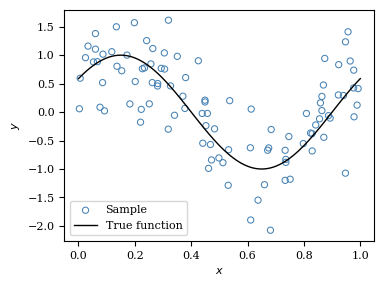

In [26]:
import matplotlib.pyplot as plt

# Plot raw data
plt.scatter(x, y, s=20, color='none', edgecolor='steelblue', lw=0.75, label='Sample')

# Plot true function on uniformly spaced grid
xvalues = np.linspace(0.0, 1.0, 101)
plt.plot(xvalues, fcn(xvalues), color='black', lw=1.0, label='True function')

plt.xlabel('$x$')
plt.ylabel('$y$')
_ = plt.legend()

#### Part 3 — Creating a pipeline

We can create a pipeline using two equivalent ways, using either
[`make_pipeline()`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) or
[`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Create pipeline. The degree value does not matter at this point, will be
# automatically updated.
pipe = make_pipeline(
    PolynomialFeatures(degree=0, include_bias=True),
    LinearRegression(fit_intercept=False),
)

Alternatively, we could have created the pipeline using 
[`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
which allows us to explicitly assign names to each pipeline step. We choose names which are the same as the default values assigned by 
[`make_pipeline()`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html):

In [28]:
from sklearn.pipeline import Pipeline

# Create pipeline, explicitly specifying step names
pipe = Pipeline(
    [
        ('polynomialfeatures', PolynomialFeatures(degree=0, include_bias=True)),
        ('linearregression', LinearRegression(fit_intercept=False)),
    ]
)

#### Part 4 — Computing the MSE for each hyperparameter

To use 
[`validation_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html),
we need to correctly specify the `param_name` argument. In our case this is given by 
`'polynomialfeatures__degree'` since we are asking the function to vary the argument `degree` of the pipeline step called
`polynomialfeatures`. Note that the `__` serves as a delimiter between the pipeline step name and the argument name.

In [29]:
from sklearn.model_selection import validation_curve

# Set of polynomial degrees to cross-validate
degrees = np.arange(16)

# Compute the MSEs for each degree and each split, returning arrays of
# size 15 x 10.
train_scores, test_scores = validation_curve(
    estimator=pipe,
    X=x[:, None],
    y=y,
    param_name='polynomialfeatures__degree',
    param_range=degrees,
    scoring='neg_mean_squared_error',
    cv=10,
)

# Compute mean and std for each degree (scores returned by function are
# NEGATIVE MSEs)
train_mse_mean = np.mean(-train_scores, axis=1)
train_mse_std = np.std(-train_scores, axis=1)
test_mse_mean = np.mean(-test_scores, axis=1)
test_mse_std = np.std(-test_scores, axis=1)

#### Part 5 — Optimal polynomial degree

The optimal cross-validated polynomial degree is the one at which the average MSE is minimized:

In [30]:
imin = np.argmin(test_mse_mean)
dmin = degrees[imin]

print(f'Polynomial degree with min. MSE: {dmin}')

Polynomial degree with min. MSE: 5


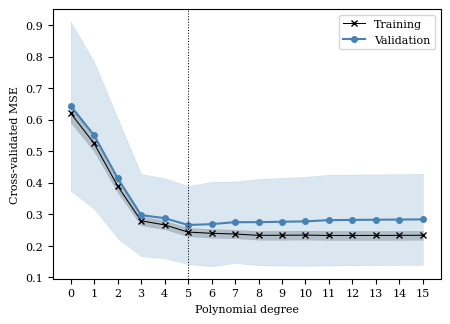

In [31]:
plt.figure(figsize=(5, 3.5))
plt.plot(
    degrees, train_mse_mean, c='black', lw=0.75, marker='x', ms=4, label='Training'
)
plt.fill_between(
    degrees,
    train_mse_mean - train_mse_std,
    train_mse_mean + train_mse_std,
    lw=0.25,
    color='black',
    alpha=0.2,
    zorder=-1,
)

plt.plot(degrees, test_mse_mean, c='steelblue', marker='o', ms=4, label='Validation')
plt.fill_between(
    degrees,
    test_mse_mean - test_mse_std,
    test_mse_mean + test_mse_std,
    lw=0.25,
    color='steelblue',
    alpha=0.2,
    zorder=-1,
)

plt.xlabel('Polynomial degree')
plt.ylabel('Cross-validated MSE')
# plt.scatter(degrees[imin], test_mse_mean[imin], s=15, c='black', zorder=100)
plt.xticks(degrees)
plt.axvline(imin, ls=':', lw=0.75, c='black')
_ = plt.legend(loc='upper right')

#### Part 6 — Plotting predicted values

We need to re-fit the model using the optimal polynomial degree. For this, we recreate the pipeline, fit the model and compute the model prediction on a grid of $x$-values.

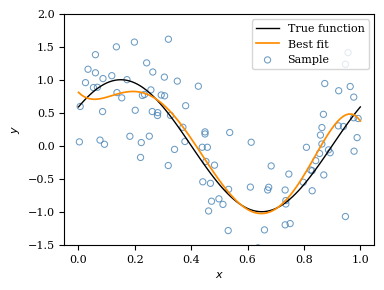

In [32]:
pipe = make_pipeline(
    PolynomialFeatures(degree=dmin, include_bias=True),
    LinearRegression(fit_intercept=False),
)

pipe.fit(x[:, None], y)

# X-values used for prediction
xvalues = np.linspace(0.0, 1.0, 101)
# Fit model
y_hat = pipe.predict(xvalues[:, None])

# Plot true relationship (w/o errors)
plt.plot(xvalues, fcn(xvalues), color='black', lw=1.0, label='True function')

# Plot best fit
plt.plot(xvalues, y_hat, color='darkorange', lw=1.25, zorder=10, label='Best fit')

# Plot sample
plt.scatter(
    x, y, s=20, color='none', edgecolor='steelblue', lw=0.75, alpha=0.8, label='Sample'
)

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.ylim(-1.5, 2.0)
_ = plt.legend(loc='upper right')